# 📊 Dataset Information

**Note:** The dataset for this project is **not included in this repository** to keep the repository lightweight.  

You can download the dataset from **Kaggle** using the link below:  

[Download The Telecom Customer Churn Dataset](https://www.kaggle.com/datasets/abbas829/telecom-customer-churn-feature-engineering-dataset)  

Please make sure to place the downloaded CSV file in the same directory as this notebook before running any code.

# Importing

## Import Library

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

/kaggle/input/datasets/abbas829/telecom-customer-churn-feature-engineering-dataset/telecom_customer_churn_feature_engineering.csv


## Import CSV And convert to DataFrame

In [2]:
df = pd.read_csv('telecom_customer_churn_feature_engineering.csv')

# Preprocessing

## Frist five row

In [3]:
df.head()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
0,10001,2019-01-01,65,Male,Multan,Bachelor,Employed,57643.0,10049.0,5.8,52.0,6-Month,1,Coverage is poor in my location,0
1,10002,2019-01-02,22,Female,Peshawar,Master,Employed,18207.0,2752.0,11.9,22.0,6-Month,2,Billing issues occurred multiple times,0
2,10003,2019-01-03,43,Male,Gujranwala,Secondary,Employed,13075.0,3155.0,40.0,87.0,Monthly,0,Billing issues occurred multiple times,0
3,10004,2019-01-04,21,Male,Lahore,Secondary,Employed,38890.0,5859.0,8.5,147.0,6-Month,2,Customer support was helpful,0
4,10005,2019-01-05,37,Female,Hyderabad,Primary,Employed,17475.0,5106.0,3.3,183.0,12-Month,0,Coverage is poor in my location,0


## last Five row

In [4]:
df.tail()

,customer_id,signup_date,age,gender,city,education_level,employment_status,monthly_income,monthly_bill,internet_usage_gb,call_minutes,contract_type,support_tickets,customer_feedback,churn
1195,11196,2022-04-10,48,Male,Gujranwala,Master,Employed,8193.0,10223.0,5.8,334.0,6-Month,1,Coverage is poor in my location,1
1196,11197,2022-04-11,54,Male,Lahore,Bachelor,Student,32480.0,3320.0,9.9,47.0,Monthly,3,Too expensive compared to competitors,1
1197,11198,2022-04-12,34,Male,Quetta,Primary,Student,42000.0,8147.0,33.0,96.0,12-Month,1,Too expensive compared to competitors,0
1198,11199,2022-04-13,20,Male,Multan,Secondary,Employed,80554.0,8427.0,14.4,157.0,Monthly,1,Service is unreliable during peak hours,0
1199,11200,2022-04-14,28,Male,Quetta,Bachelor,Employed,49647.0,4074.0,16.0,126.0,12-Month,1,Service is unreliable during peak hours,0


## Shape of our dataset

In [5]:
df.shape

(1200, 15)

## List out all columns

In [6]:
df.columns

Index(['customer_id', 'signup_date', 'age', 'gender', 'city',
       'education_level', 'employment_status', 'monthly_income',
       'monthly_bill', 'internet_usage_gb', 'call_minutes', 'contract_type',
       'support_tickets', 'customer_feedback', 'churn'],
      dtype='object')

## Datatype of each columns

In [7]:
df.dtypes

customer_id            int64
signup_date           object
age                    int64
gender                object
city                  object
education_level       object
employment_status     object
monthly_income       float64
monthly_bill         float64
internet_usage_gb    float64
call_minutes         float64
contract_type         object
support_tickets        int64
customer_feedback     object
churn                  int64
dtype: object

## Information of all Columns

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   customer_id        1200 non-null   int64  
 1   signup_date        1200 non-null   object 
 2   age                1200 non-null   int64  
 3   gender             1200 non-null   object 
 4   city               1200 non-null   object 
 5   education_level    1200 non-null   object 
 6   employment_status  1200 non-null   object 
 7   monthly_income     1200 non-null   float64
 8   monthly_bill       1200 non-null   float64
 9   internet_usage_gb  1200 non-null   float64
 10  call_minutes       1200 non-null   float64
 11  contract_type      1200 non-null   object 
 12  support_tickets    1200 non-null   int64  
 13  customer_feedback  1200 non-null   object 
 14  churn              1200 non-null   int64  
dtypes: float64(4), int64(4), object(7)
memory usage: 140.8+ KB


## Check Null Value

In [9]:
df.isnull().sum()

customer_id          0
signup_date          0
age                  0
gender               0
city                 0
education_level      0
employment_status    0
monthly_income       0
monthly_bill         0
internet_usage_gb    0
call_minutes         0
contract_type        0
support_tickets      0
customer_feedback    0
churn                0
dtype: int64

## Check Dupicate Value

In [10]:
df.duplicated().sum()

np.int64(0)

## Summary

In [11]:
df.describe()

,customer_id,age,monthly_income,monthly_bill,internet_usage_gb,call_minutes,support_tickets,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,10600.500000,43.483333,31155.975833,5939.150833,20.152417,182.830833,1.193333,0.350000
std,346.554469,15.205176,19351.937726,4046.473963,12.174714,106.567558,1.084098,0.477168
min,10001.000000,18.000000,4984.000000,710.000000,1.100000,14.000000,0.000000,0.000000
25%,10300.750000,30.000000,17795.000000,3291.750000,11.100000,106.000000,0.000000,0.000000
50%,10600.500000,43.000000,26628.000000,4871.000000,17.800000,164.000000,1.000000,0.000000
75%,10900.250000,57.000000,39886.250000,7485.500000,26.700000,235.000000,2.000000,1.000000
max,11200.000000,69.000000,209790.000000,36361.000000,82.200000,865.000000,6.000000,1.000000


# EDA

In [12]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

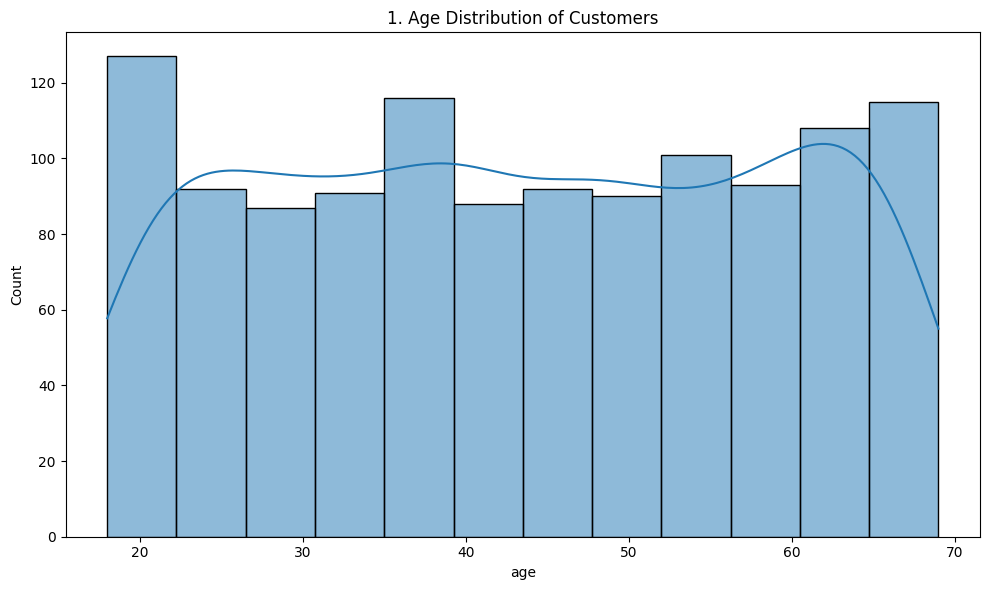

In [13]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df['age'], kde=True)
plt.title(f'{plot_no}. Age Distribution of Customers')
show_fig()
plot_no += 1

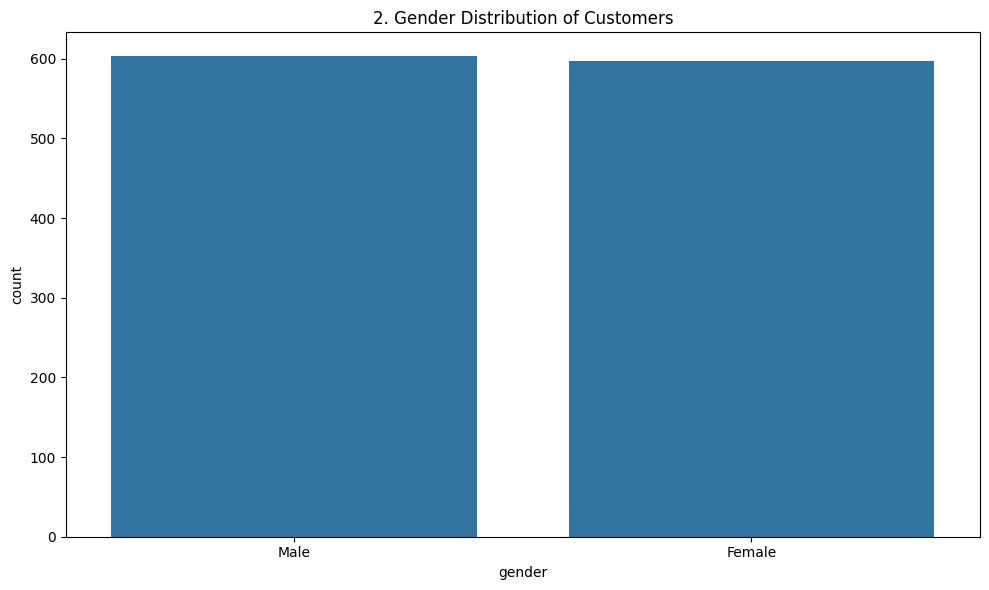

In [14]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='gender', data=df)
plt.title(f'{plot_no}. Gender Distribution of Customers')
show_fig()
plot_no += 1

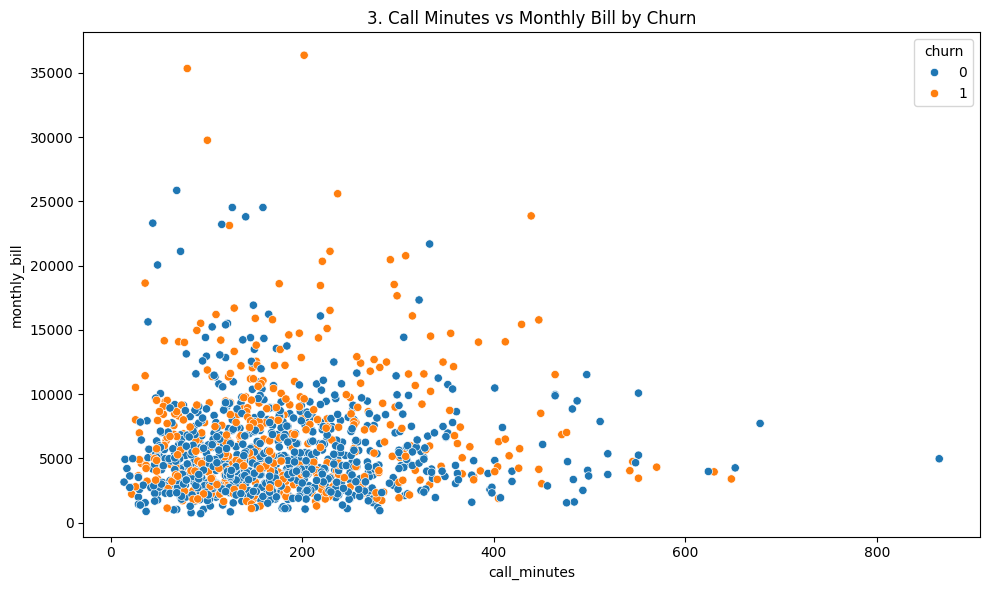

In [15]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='call_minutes', y='monthly_bill', hue='churn', data=df)
plt.title(f'{plot_no}. Call Minutes vs Monthly Bill by Churn')
show_fig()
plot_no += 1

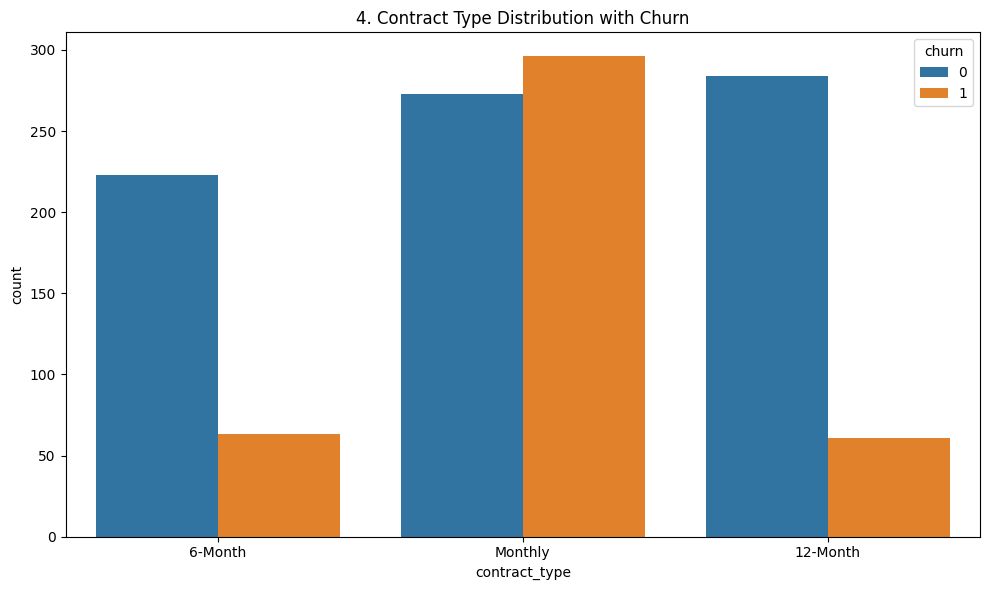

In [16]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='contract_type', hue='churn', data=df)
plt.title(f'{plot_no}. Contract Type Distribution with Churn')
show_fig()
plot_no += 1

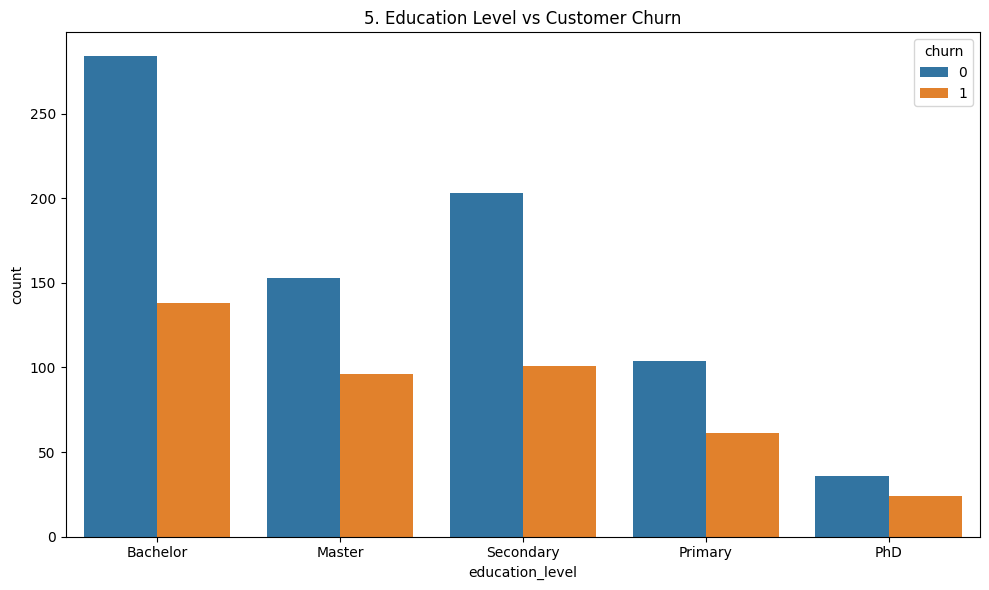

In [17]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='education_level', hue='churn', data=df)
plt.title(f'{plot_no}. Education Level vs Customer Churn')
show_fig()
plot_no += 1

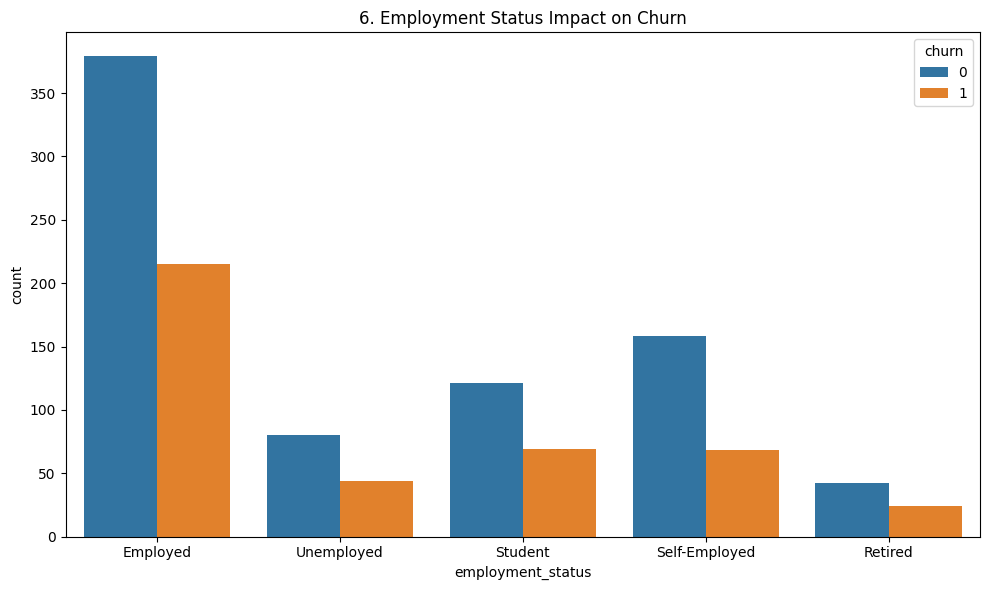

In [18]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='employment_status', hue='churn', data=df)
plt.title(f'{plot_no}. Employment Status Impact on Churn')
show_fig()
plot_no += 1

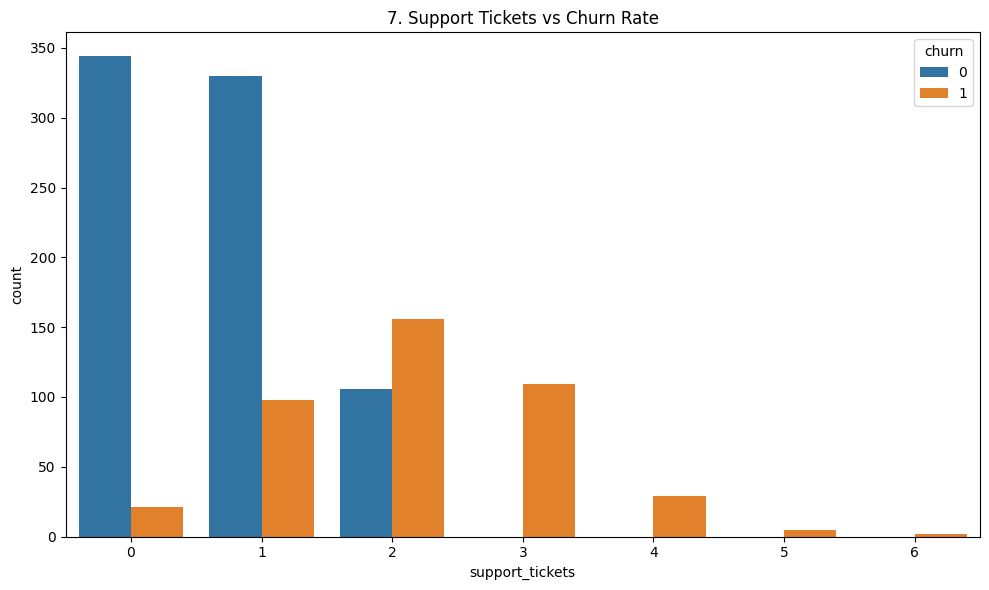

In [19]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='support_tickets', hue='churn', data=df)
plt.title(f'{plot_no}. Support Tickets vs Churn Rate')
show_fig()
plot_no += 1

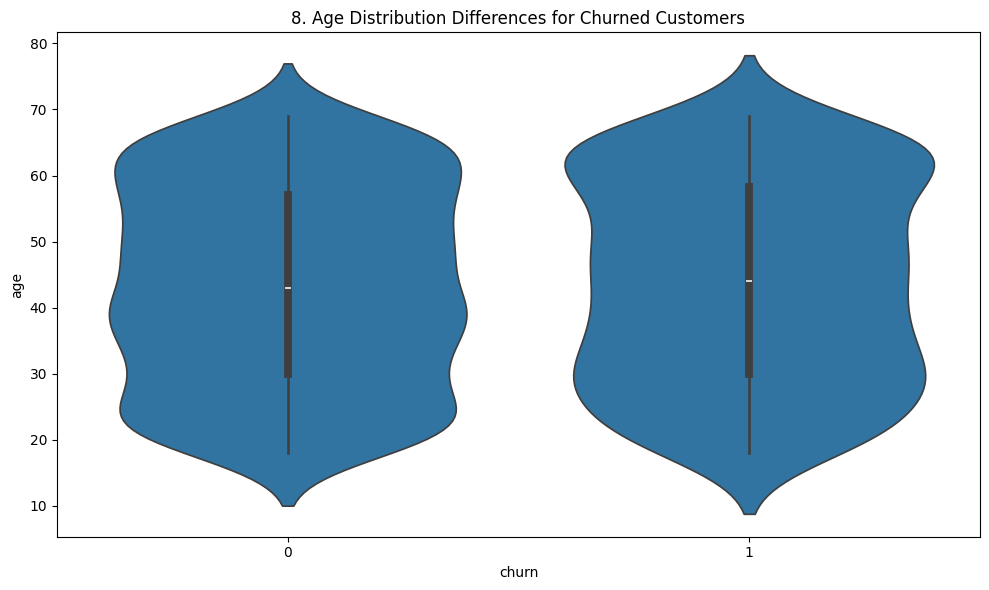

In [20]:
fig = plt.figure(figsize=(10,6))
sns.violinplot(x='churn', y='age', data=df)
plt.title(f'{plot_no}. Age Distribution Differences for Churned Customers')
show_fig()
plot_no += 1

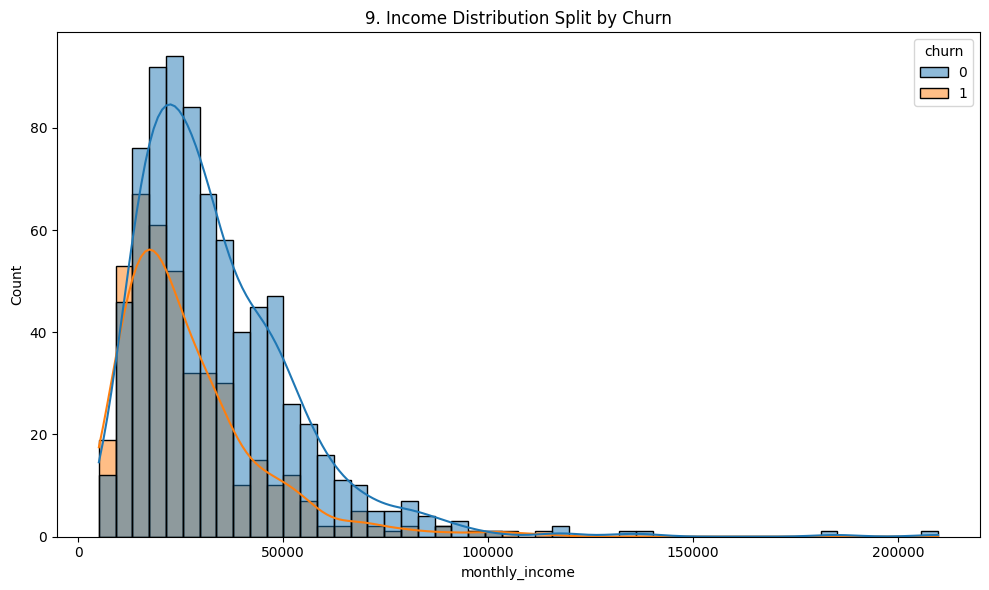

In [21]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='monthly_income', hue='churn', kde=True)
plt.title(f'{plot_no}. Income Distribution Split by Churn')
show_fig()
plot_no += 1

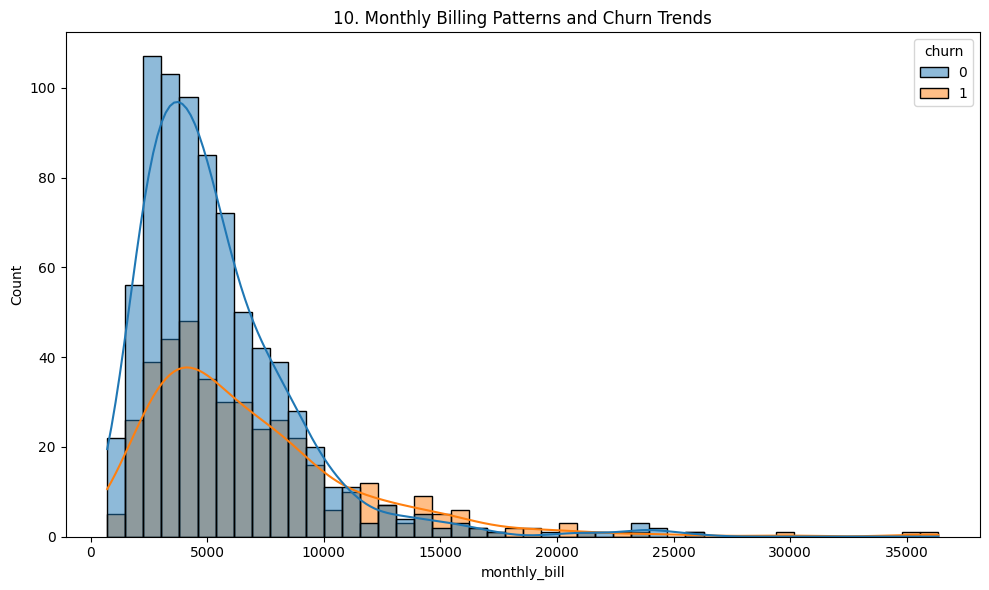

In [22]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='monthly_bill', hue='churn', kde=True)
plt.title(f'{plot_no}. Monthly Billing Patterns and Churn Trends')
show_fig()
plot_no += 1

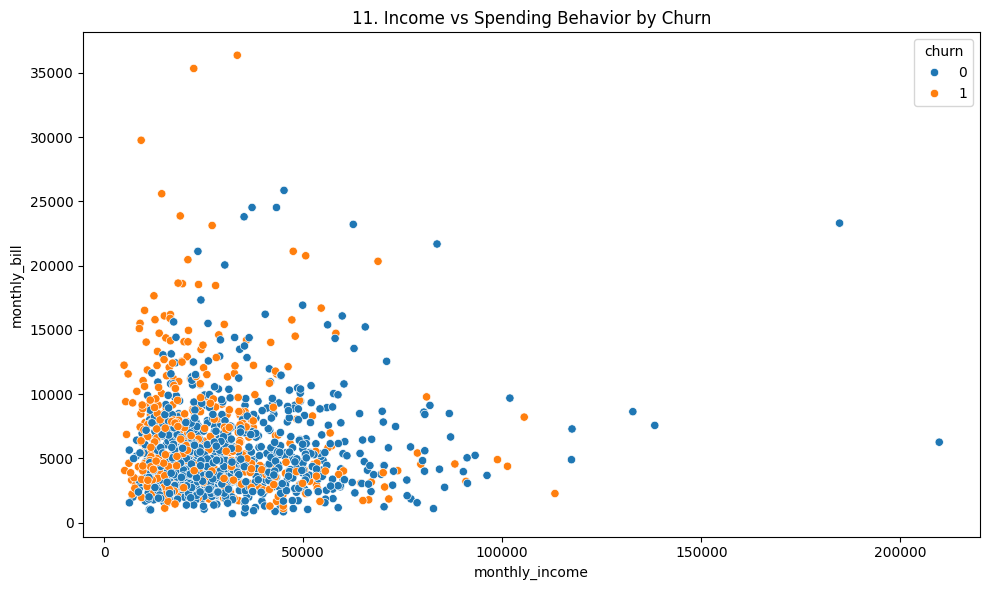

In [23]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(x='monthly_income', y='monthly_bill', hue='churn', data=df)
plt.title(f'{plot_no}. Income vs Spending Behavior by Churn')
show_fig()
plot_no += 1

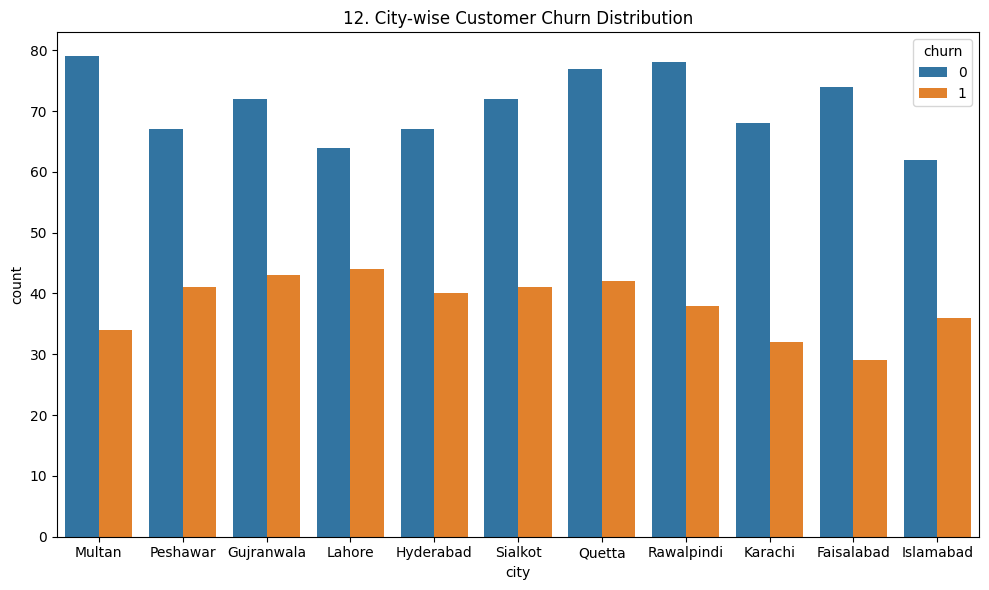

In [24]:
fig = plt.figure(figsize=(10,6))
sns.countplot(x='city', hue='churn', data=df)
plt.title(f'{plot_no}. City-wise Customer Churn Distribution')
show_fig()
plot_no += 1

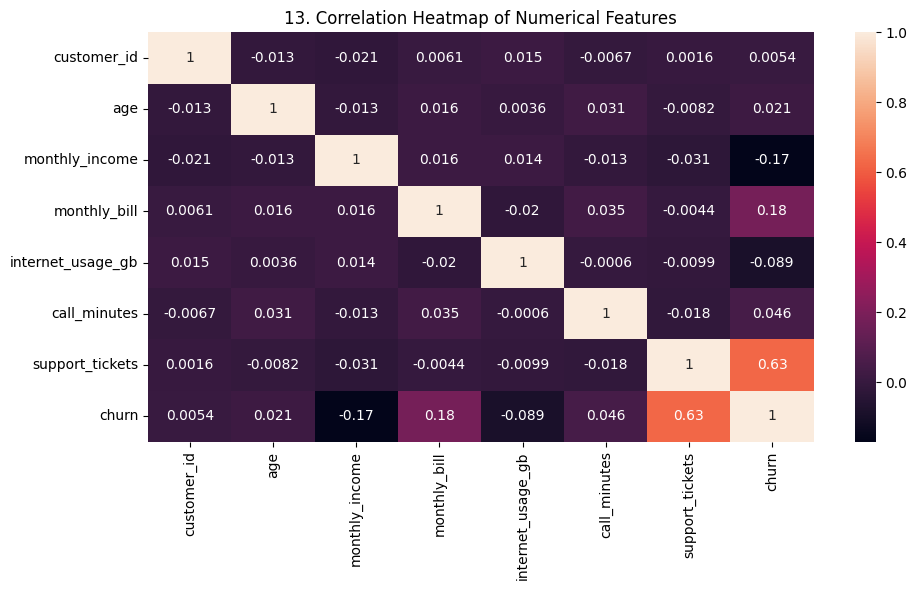

In [25]:
fig = plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=['int64','float64']).corr()
sns.heatmap(corr, annot=True)
plt.title(f'{plot_no}. Correlation Heatmap of Numerical Features')
show_fig()
plot_no += 1

# Model Training

## convert categorical columns using one-hot encoding

In [26]:
df_encoded = pd.get_dummies(df, drop_first=True)

## define features and target

In [27]:
X = df_encoded.drop('churn', axis=1)
y = df_encoded['churn']

## split dataset into train and test

In [28]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## scale numerical features

In [29]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## initialize and train model

In [30]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## make predictions

In [31]:
y_pred = model.predict(X_test)

## calculate accuracy

In [32]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7958333333333333


## plot confusion matrix

<Figure size 1000x600 with 0 Axes>

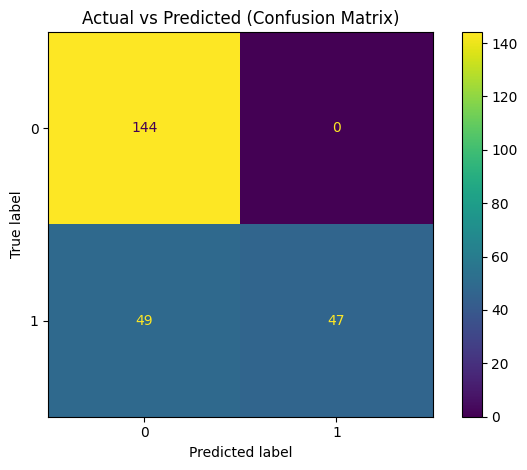

In [33]:
fig = plt.figure(figsize=(10,6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title('Actual vs Predicted (Confusion Matrix)')
plt.tight_layout()
plt.show()